## Analyze representation similarity of vocabulary of learned embeddings accross multiple instances of model training

In [196]:
import os, sys, json
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

sys.path.append('../../../')
from polygene.model.model import load_trained_model

max_number_of_checkpoints = 14
reference_model_path = "/media/lleger/LaCie/mit/runs/polygene_unit_sphere/"
model, tokenizer = load_trained_model(reference_model_path, checkpoint_n=max_number_of_checkpoints-1)

def count_model_parameters(model, exclude = "embedding"):
    return sum(parameter.numel() for name, parameter in model.named_parameters() if exclude not in name)
print(count_model_parameters(model, exclude="none"))

from polygene.data_utils.tokenization import normalise_str
#disease_indices = [tokenizer.token_to_id_map[normalise_str(idx)] for idx in tokenizer.phenotypic_tokens_map['disease']]
disease_celltype_indices = [tokenizer.token_to_id_map[normalise_str(idx)] for idx in tokenizer.phenotypic_tokens_map['disease'] + tokenizer.phenotypic_tokens_map['cell_type']]
get_learned_embeddings = lambda model: model.embeddings.token_value_embeddings.weight.detach().cpu().numpy()[disease_celltype_indices]
reference_embeddings = get_learned_embeddings(model)
reference_embeddings.shape

loading checkpoint-700000
17379121


(687, 240)

In [470]:
def cka(X, Y):
    H = np.eye(X.shape[0]) - np.ones((X.shape[0], X.shape[0]))/X.shape[0]
    K = H @ (X @ X.T) @ H
    L = H @ (Y @ Y.T) @ H
    return np.sum(K*L)/np.sqrt(np.sum(K*K)*np.sum(L*L))

from sklearn.metrics import pairwise_distances
def mknn(X, Y, k):
    dist_x = pairwise_distances(X)
    dist_y = pairwise_distances(Y)
    nn_x = np.argsort(dist_x, axis=1)[:, 1:k+1]
    nn_y = np.argsort(dist_y, axis=1)[:, 1:k+1]
    overlap = [len(set(nn_x[i]) & set(nn_y[i])) / k for i in range(X.shape[0])]
    return np.mean(overlap)

batch_size=32
model_complexity_ablations_path = "/media/lleger/LaCie/mit/runs/plato/"

representation_alignment = {}
for idx, model_path in enumerate([reference_model_path] + [model_complexity_ablations_path + file + '/' for file in os.listdir(model_complexity_ablations_path)]):
    
    model_name = model_path.split('/')[-2]
    representation_alignment[model_name] = {}
    model, tokenizer = load_trained_model(model_path, checkpoint_n=0)

    representation_alignment[model_name]['inference_complexity'] = count_model_parameters(model, exclude="embedding")
    representation_alignment[model_name]['total_degrees_of_freedom'] =count_model_parameters(model, exclude="none")

    checkpoints = [checkpoint for checkpoint in os.listdir(model_path) if "checkpoint" in checkpoint][:max_number_of_checkpoints]
    representation_alignment[model_name]["number_of_cells"] = [int(checkpoint.split('-')[-1]) * batch_size for checkpoint in checkpoints]

    model_checkpoints = [load_trained_model(model_path, checkpoint_n)[0] for checkpoint_n in range(len(checkpoints))]

    k_neighbors = k = int(.05 * len(reference_embeddings))
    representation_alignment[model_name]["centered_kernel_alignment"] = [cka(get_learned_embeddings(m), reference_embeddings) for m in model_checkpoints]
    representation_alignment[model_name]["mutual_k_nearest_neighbors"] = [mknn(get_learned_embeddings(m), reference_embeddings, k) for m in model_checkpoints]

loading checkpoint-3125
loading checkpoint-3125
loading checkpoint-5212
loading checkpoint-8695
loading checkpoint-14504
loading checkpoint-24195
loading checkpoint-40360
loading checkpoint-67326
loading checkpoint-112306
loading checkpoint-187338
loading checkpoint-312500
loading checkpoint-400000
loading checkpoint-500000
loading checkpoint-600000
loading checkpoint-700000
loading checkpoint-3125
loading checkpoint-3125
loading checkpoint-5212
loading checkpoint-8695
loading checkpoint-14504
loading checkpoint-24195
loading checkpoint-40360
loading checkpoint-67326
loading checkpoint-112306
loading checkpoint-187338
loading checkpoint-312500
loading checkpoint-400000
loading checkpoint-500000
loading checkpoint-600000
loading checkpoint-700000
loading checkpoint-3125
loading checkpoint-3125
loading checkpoint-5212
loading checkpoint-8695
loading checkpoint-14504
loading checkpoint-24195
loading checkpoint-40360
loading checkpoint-67326
loading checkpoint-112306
loading checkpoint-187

dict_keys(['polygene_unit_sphere', '_seed_2_layers_6_dim_240', '_seed_3_layers_1_dim_240', '_seed_3_layers_3_dim_240', '_seed_3_layers_6_dim_96', '_seed_3_layers_6_dim_144'])
polygene_unit_sphere
_seed_2_layers_6_dim_240
_seed_3_layers_3_dim_240
_seed_3_layers_6_dim_144
_seed_3_layers_1_dim_240
_seed_3_layers_6_dim_96
0.15354072789520043 0.7787318007931092


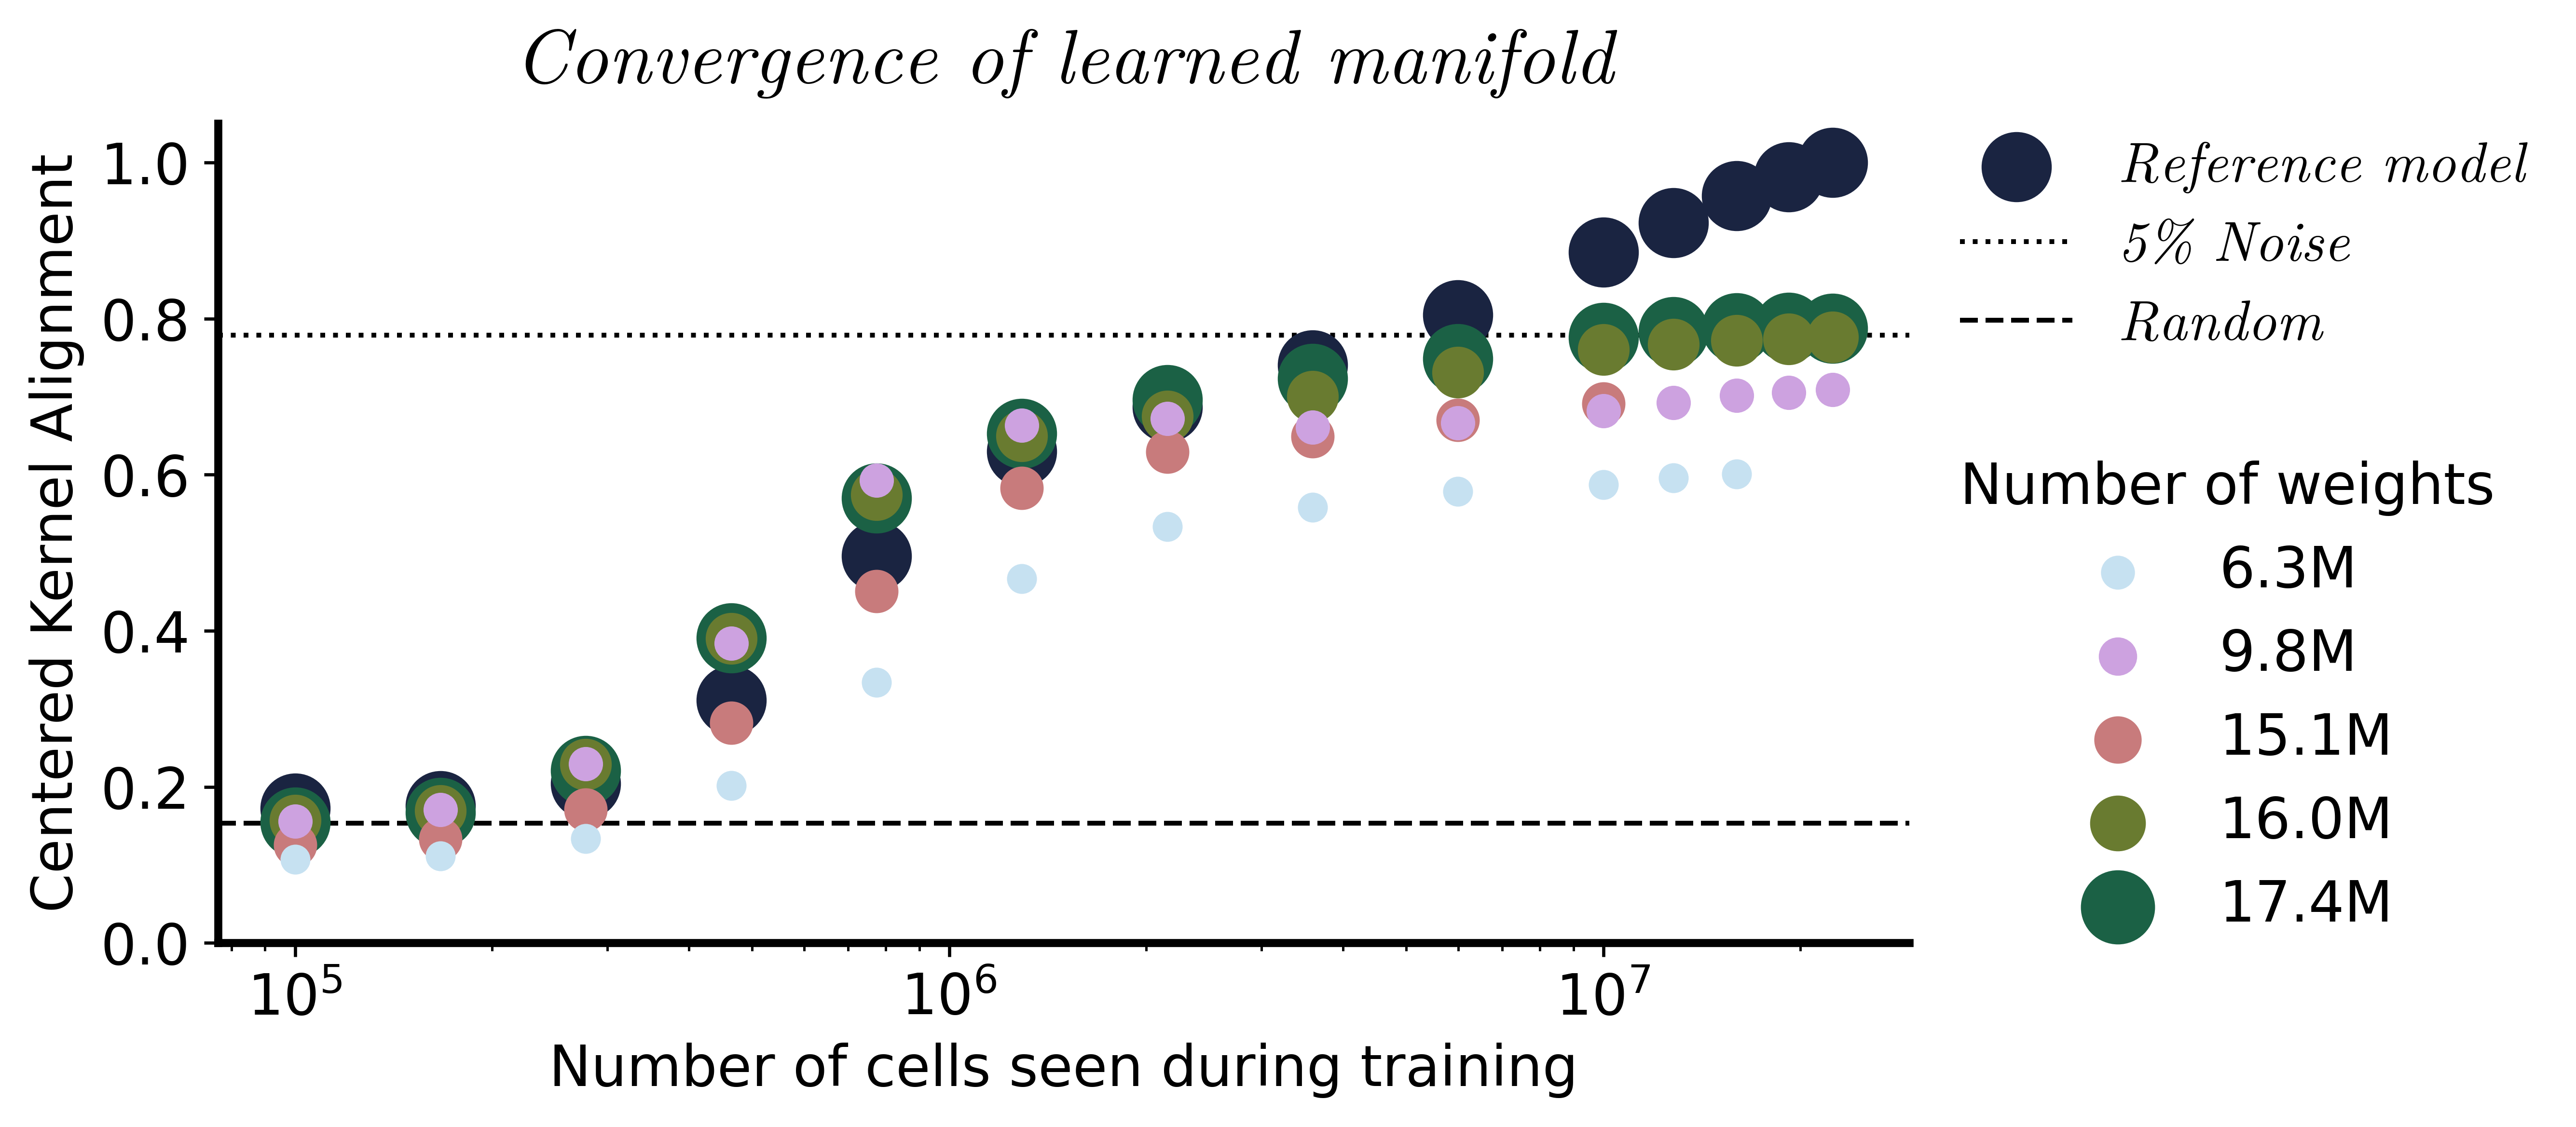

In [481]:

fig, ax = plt.subplots(1,1, figsize=(9, 4), dpi=600)
print(representation_alignment.keys())
fontsize = 14
markersize = 200
size_function = lambda c: markersize*c/2e6
palette_name = "cividis"
palette_name = "Purples"
palette_name = "Greys"
palette_name = "cubehelix"
palette = sns.color_palette(palette_name, n_colors=len(representation_alignment))

from matplotlib.legend import Legend
for idx, model_name in enumerate(sorted(representation_alignment, key=lambda x: representation_alignment[x]['inference_complexity'], reverse=True)):
    number_of_cells = representation_alignment[model_name]['number_of_cells']
    centered_kernel_alignment = representation_alignment[model_name]['mutual_k_nearest_neighbors']
    centered_kernel_alignment = representation_alignment[model_name]['centered_kernel_alignment']
    complexity = int(representation_alignment[model_name]['inference_complexity'])
    #print(centered_kernel_alignment)
    #print()

    color = palette[idx]
    print(model_name)
    ax.scatter(number_of_cells, centered_kernel_alignment, s=size_function(complexity), color= color, alpha=1,lw=0,
               label="Reference model" if "polygene" in model_name else None)
    #break

alpha=5e-2
np.random.seed(5)
corruption_matrix = np.random.normal(0, 1, size=reference_embeddings.shape ) #(reference_embeddings, axis=-1, keepdims=True)
generate_corrupted_embeddings = lambda X, alpha: (1-alpha)*X + alpha*corruption_matrix
random_alignment = cka(reference_embeddings, generate_corrupted_embeddings(reference_embeddings, alpha=1))

corrupted= generate_corrupted_embeddings(reference_embeddings, alpha=alpha)
small_corruption_alignment = cka(reference_embeddings,corrupted)

bounds_color = "k"
bounds_alpha = 1
lw = 1.2
plt.axhline(y=small_corruption_alignment, zorder=-5, color=bounds_color, ls="dotted", label="5% Noise", alpha=bounds_alpha, lw=lw)
plt.axhline(y=random_alignment, zorder=-5, color=bounds_color, ls="--", label="Random", alpha=bounds_alpha, lw=lw)
print(random_alignment, small_corruption_alignment)

ax.legend(bbox_to_anchor=(1, 0.85), fontsize=14, frameon=False, loc="center left", prop={'family': 'Latin Modern Roman', 'style': 'italic', 'size': fontsize})

ax.set_xscale('log')
ax.set_ylim(0, 1.05)
ax.set_xlabel("Number of cells seen during training \n (tens of millions)", fontsize=fontsize)
ax.set_xlabel("Number of cells seen during training", fontsize=fontsize)
ax.set_ylabel("Centered Kernel Alignment", fontsize=fontsize)
ax.tick_params('both', labelsize=fontsize)

model_complexities = np.unique([representation_alignment[name]['inference_complexity'] for name in representation_alignment])#[::2]
model_complexities = sorted([representation_alignment[name]['inference_complexity'] for name in representation_alignment])#[:-1]
handles = [ax.scatter([], [], s=size_function(size), color=sns.color_palette(palette_name, n_colors=len(model_complexities))[::-1][sdx]) for sdx, size in enumerate(model_complexities)][:-1]
units = ['', 'K', 'M', 'B', 'T']
model_complexities = np.unique([representation_alignment[name]['total_degrees_of_freedom'] for name in representation_alignment])#[::2]
model_complexities = sorted([representation_alignment[name]['total_degrees_of_freedom'] for name in representation_alignment])#[:-1]
size_readable = lambda v:f"{v / 10**(int(np.log10(v) // 3)*3):.1f}{units[int(np.log10(v) // 3)]}"
labels = [size_readable(size) for size in model_complexities][:-1]
model_size_legend = Legend(ax, handles, labels, bbox_to_anchor=(1, 0.3), loc="center left",
                            frameon=False, title="Number of weights", alignment="center", title_fontsize=fontsize, fontsize=fontsize) 


ax.add_artist(model_size_legend)
ax.spines[['top', 'right']].set_linewidth(0)
ax.spines[['bottom', 'left']].set_linewidth(2)
ax.set_title('Convergence of learned manifold', fontsize=fontsize+5, y=1.02, fontdict={"fontsize": fontsize+5, "fontfamily": "Latin Modern Roman", "style": "italic"})
plt.tight_layout()
plt.savefig("representation_convergence_logscale.png", dpi=600)
#plt.savefig("representation_convergence.png", dpi=600)
plt.show()

In [457]:
np.sqrt(2e-3)

0.044721359549995794